### 验证投影近似是否正确



In [2]:
import numpy as np
import matplotlib.pyplot as plt

data_bg = np.load('SE_bg.npz', allow_pickle=True) # 读取npz文件，返回一个字典
data_s1 = np.load('SE_disSG2_Sph40um_0.05.npz', allow_pickle=True) # 读取npz文件，返回一个字典

print('npz文件保存的文件包括: ', data_bg.files) # 打印全部文件名
print('npz文件保存的文件包括: ', data_s1.files) # 打印全部文件名

npz文件保存的文件包括:  ['Vis']
npz文件保存的文件包括:  ['Vis', 'AutoCorrLen']


In [3]:
Vis_bg = data_bg['Vis']
Vis_s1 = data_s1['Vis']
xi = np.squeeze(data_s1['AutoCorrLen'])
print(xi)


[8.61001389e-07 1.72200278e-06 2.58300417e-06 3.44400556e-06
 4.30500694e-06 5.16600833e-06]


In [4]:
data_bg.close() # 关闭文件
data_s1.close() # 关闭文件

In [5]:
df = Vis_s1/Vis_bg


In [8]:
## 稀疏小球理论暗场计算
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import pi

# 常量定义
R = 20e-6  # 小球半径，单位：m
V = 4/3*pi*R**3  # 小球体积
r_e = 2.81e-15  # 电子半径，单位：m
rho_e = 3.86e29  # PMMA 密度，单位：m^-3
delta_rho = rho_e * r_e  # 密度差，单位：m^-2
E = 30 # the design energy of the grating interferometer [unit: keV]
lambda_ = 1.239842e-9 / E  # wavelength of the design energy [unit: m]

t = 2.4e-4  # 样品厚度，单位：m
VF = 0.0485  # 体积分数

# 定义投影函数 f3
def f3(x):
    term1 = (1 - (x / (2 * R))**2)**0.5 * (1 + x**2 / (8 * R**2))
    term2 = (x**2 / (2 * R**2)) * (1 - (x / (4 * R))**2) * np.log(x / (R * (2 + (4 - (x / R)**2)**0.5)))
    return term1 + term2

# 计算投影函数 G
G = np.vectorize(f3)(xi)
if xi[0] == 0:
    G[0] = 1 

# 计算暗场比值 DF_theory
G0 = 3 * VF * delta_rho**2 * lambda_**2 * R / 2 
DF_theory = np.exp(t * G0 * (np.real(G) - 1))


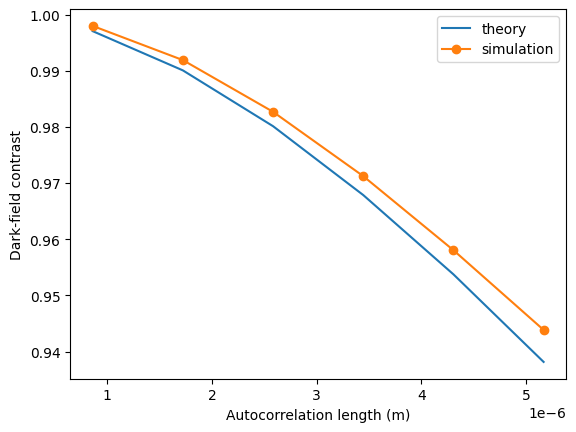

In [9]:
xi = np.squeeze(xi)
df = np.squeeze(df)
# compare the simulation and theory
plt.figure()
plt.plot(xi, DF_theory, label='theory')
plt.errorbar(xi, df, capsize=5, fmt='-o', label='simulation')
plt.legend(loc='upper right')
plt.xlabel('Autocorrelation length (m)')
plt.ylabel('Dark-field contrast')
plt.show()